# Class 01 — Experimental Design
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

Experimental design is the machinery that lets us answer "does X cause Y?" cleanly. Without it, confounders, bias, and noise make causal claims unreliable. This notebook builds the core concepts from scratch.

**Contents:**
1. [Setup](#1)
2. [The Confounding Problem](#2)
3. [Randomization — Covariate Balance](#3)
4. [CRD vs. Randomized Block Design](#4)
5. [Factorial Design — Interactions Matter](#5)
6. [Internal vs. External Validity](#6)
7. [Meta-Analysis — Pooling Evidence](#7)

---

<a id='1'></a>
## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import product

np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'; ORANGE='#D97706'; GRAY='#6B7280'
print('Ready.')

Ready.


<a id='2'></a>
## 2. The Confounding Problem

A **confounder** correlates with both X and Y, creating a spurious apparent causal relationship.

**Classic example (from slides):** Ice cream sales correlate with drowning deaths. The confounder is summer heat — it drives both. Controlling for it eliminates the apparent correlation entirely.

In [6]:
n = 1000
temperature = np.random.binomial(1, 0.5, n)
ice_cream   = 2*temperature + np.random.normal(0, 0.5, n)
drowning    = 3*temperature + np.random.normal(0, 0.5, n)
df_conf     = pd.DataFrame({'temperature':temperature,'ice_cream':ice_cream,'drowning':drowning})

r_naive, p_naive = stats.pearsonr(ice_cream, drowning)
r_cool, _ = stats.pearsonr(df_conf[df_conf.temperature==0]['ice_cream'],
                            df_conf[df_conf.temperature==0]['drowning'])
r_hot, _  = stats.pearsonr(df_conf[df_conf.temperature==1]['ice_cream'],
                            df_conf[df_conf.temperature==1]['drowning'])

print(f'Naive correlation (ignoring confounder): r = {r_naive:.3f}, p = {p_naive:.2e}')
print(f'Partial correlation (cool days only):    r = {r_cool:.3f}')
print(f'Partial correlation (hot  days only):    r = {r_hot:.3f}')
print('Controlling for the confounder eliminates the spurious effect.')

Naive correlation (ignoring confounder): r = 0.850, p = 3.16e-280
Partial correlation (cool days only):    r = 0.031
Partial correlation (hot  days only):    r = -0.069
Controlling for the confounder eliminates the spurious effect.


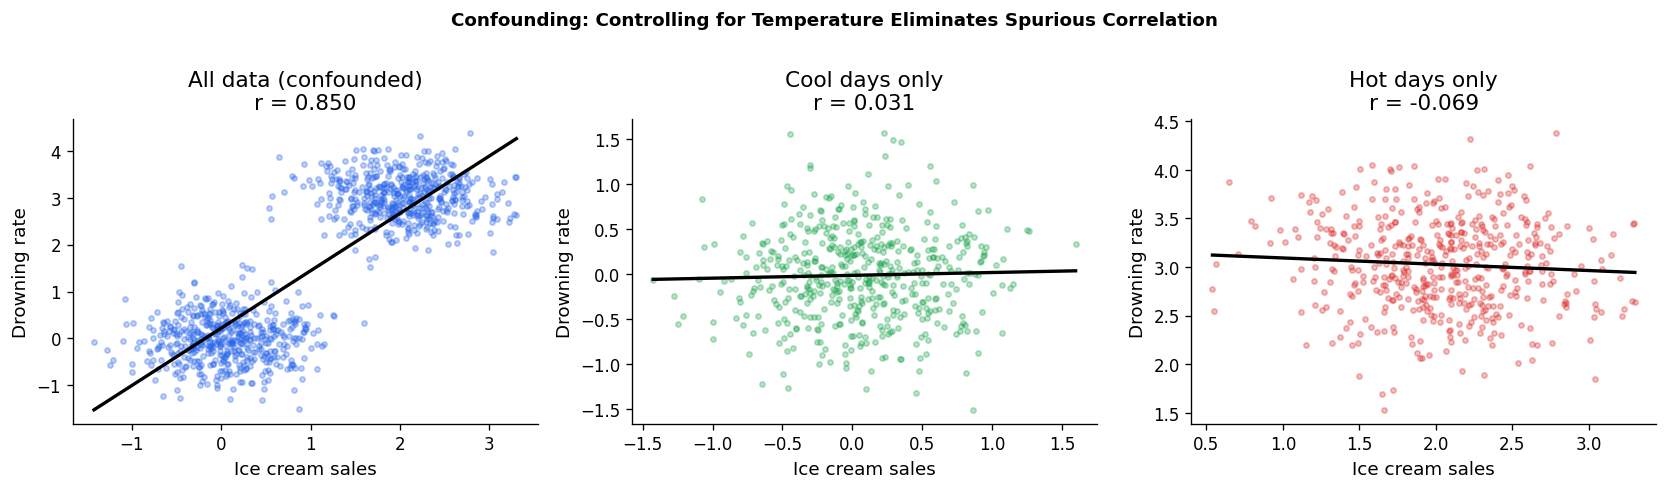

Saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (mask, label, col) in zip(axes, [
    (np.ones(n,bool), 'All data (confounded)', BLUE),
    (temperature==0,  'Cool days only',         GREEN),
    (temperature==1,  'Hot days only',           RED)
]):
    r, _ = stats.pearsonr(ice_cream[mask], drowning[mask])
    ax.scatter(ice_cream[mask], drowning[mask], alpha=0.3, s=10, color=col)
    m, b = np.polyfit(ice_cream[mask], drowning[mask], 1)
    xr = np.linspace(ice_cream[mask].min(), ice_cream[mask].max(), 100)
    ax.plot(xr, m*xr+b, color='black', lw=2)
    ax.set_title(f'{label}\nr = {r:.3f}')
    ax.set_xlabel('Ice cream sales'); ax.set_ylabel('Drowning rate')
plt.suptitle("Confounding: Controlling for Temperature Eliminates Spurious Correlation",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_confounding.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='3'></a>
## 3. Randomization — Covariate Balance

Randomization guarantees that **all** covariates — measured and unmeasured — are balanced between groups. Self-selection (observational) creates systematic imbalance.

In [8]:
n_pop = 500
age   = np.random.normal(45, 12, n_pop)
bmi   = np.random.normal(27,  5, n_pop)
bp    = np.random.normal(120,15, n_pop)

# Observational: high-risk people self-select into treatment
risk_score = (age-45)/12 + (bmi-27)/5
p_treat    = 1 / (1 + np.exp(-risk_score))
T_obs = np.random.binomial(1, p_treat)

# RCT: coin flip
T_rct = np.random.binomial(1, 0.5, n_pop)

print(f'{"Covariate":<12} {"Obs Treat":>10} {"Obs Ctrl":>10} {"Diff":>8} | {"RCT Treat":>10} {"RCT Ctrl":>10} {"Diff":>8}')
print('-'*72)
for name, vals in [('Age', age), ('BMI', bmi), ('Blood Pr.', bp)]:
    ot=vals[T_obs==1].mean(); oc=vals[T_obs==0].mean()
    rt=vals[T_rct==1].mean(); rc=vals[T_rct==0].mean()
    print(f'{name:<12} {ot:>10.1f} {oc:>10.1f} {ot-oc:>+8.1f} | {rt:>10.1f} {rc:>10.1f} {rt-rc:>+8.1f}')

Covariate     Obs Treat   Obs Ctrl     Diff |  RCT Treat   RCT Ctrl     Diff
------------------------------------------------------------------------
Age                49.5       39.7     +9.8 |       44.9       44.1     +0.9
BMI                29.1       25.1     +4.0 |       27.0       27.2     -0.2
Blood Pr.         119.2      118.1     +1.0 |      118.8      118.4     +0.4


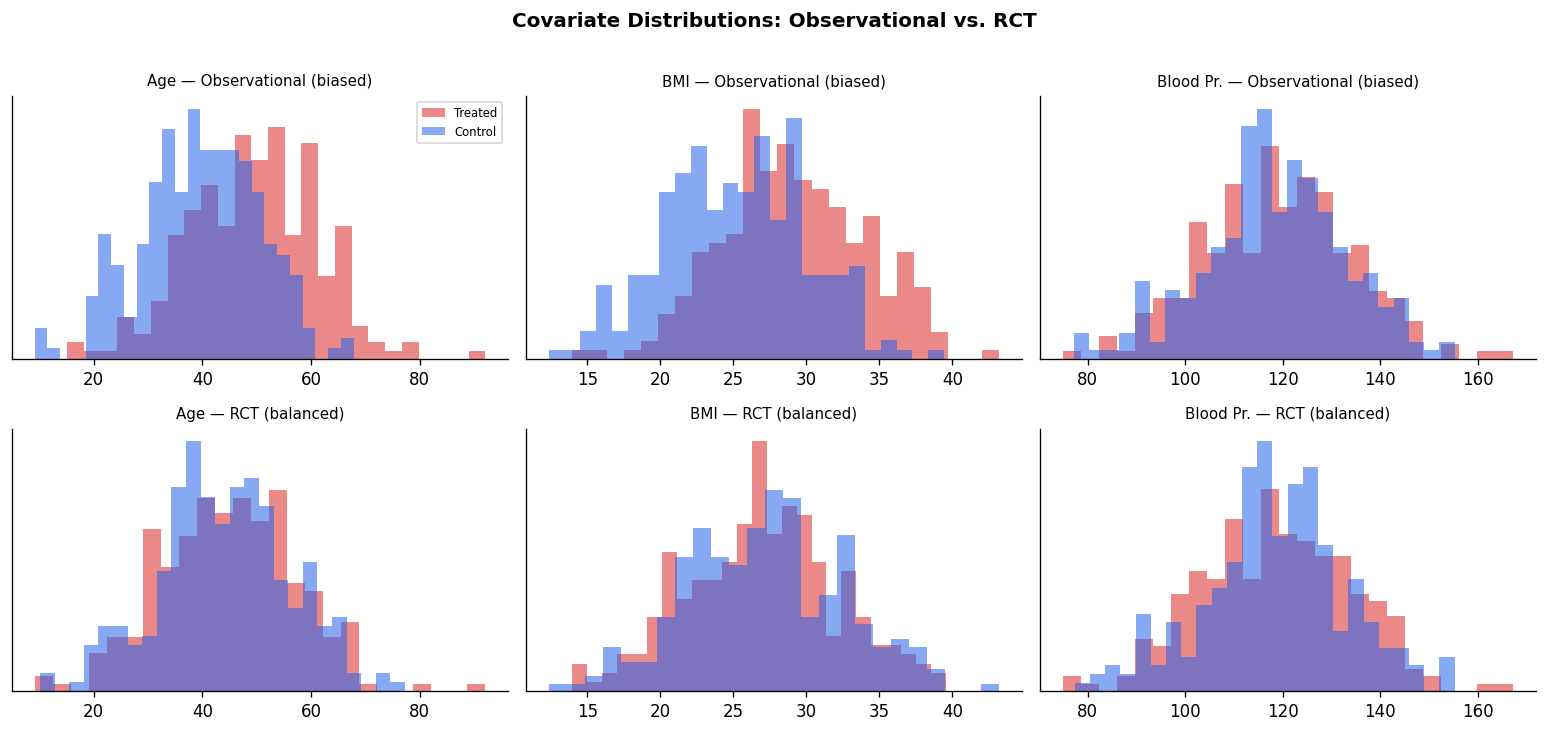

Saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for col_idx, (name, vals) in enumerate([('Age',age),('BMI',bmi),('Blood Pr.',bp)]):
    for row_idx, (T, title) in enumerate([(T_obs,'Observational (biased)'),(T_rct,'RCT (balanced)')]):
        ax = axes[row_idx][col_idx]
        for t_val, label, color in [(1,'Treated',RED),(0,'Control',BLUE)]:
            ax.hist(vals[T==t_val], bins=25, alpha=0.55, color=color, density=True, label=label)
        ax.set_title(f'{name} — {title}', fontsize=9); ax.set_yticks([])
        if col_idx==0 and row_idx==0: ax.legend(fontsize=7)
plt.suptitle('Covariate Distributions: Observational vs. RCT',fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('figures/02_randomization_balance.png',bbox_inches='tight')
plt.show(); print('Saved.')

<a id='4'></a>
## 4. CRD vs. Randomized Block Design

**Blocking** removes a known source of variance before randomizing. If gender strongly affects the outcome, blocking on gender reduces noise and increases power.

CRD SD: 0.389  |  RBD SD: 0.139
Variance reduction from blocking: 87.3%


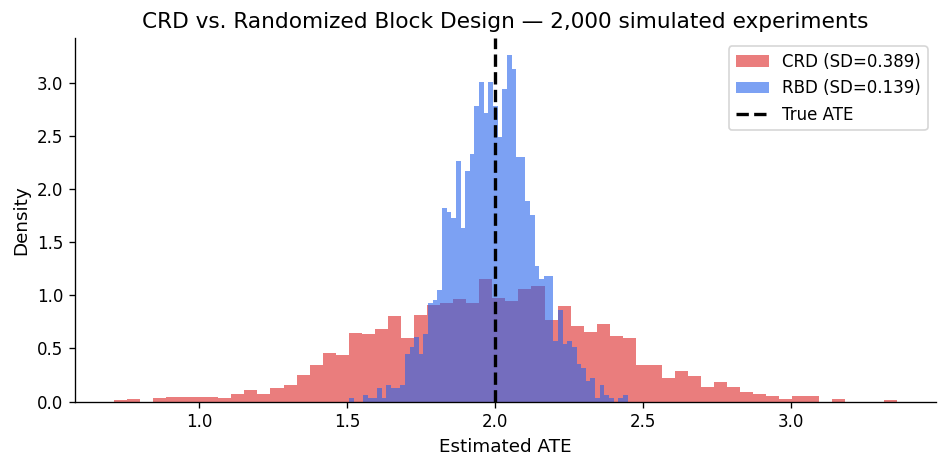

Saved.


In [10]:
def simulate_ate(n=200, true_ate=2.0, block_effect=5.0, design='CRD', n_sims=2000, seed=0):
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(n_sims):
        gender = rng.integers(0, 2, n)
        if design == 'CRD':
            T = rng.integers(0, 2, n)
        else:
            T = np.zeros(n, dtype=int)
            for g in [0,1]:
                idx = np.where(gender==g)[0]
                T[idx[:len(idx)//2]] = 1
        Y = true_ate*T + block_effect*gender + rng.normal(0, 1, n)
        estimates.append(Y[T==1].mean() - Y[T==0].mean())
    return np.array(estimates)

ates_crd = simulate_ate(design='CRD')
ates_rbd = simulate_ate(design='RBD')
print(f'CRD SD: {ates_crd.std():.3f}  |  RBD SD: {ates_rbd.std():.3f}')
print(f'Variance reduction from blocking: {(1-ates_rbd.var()/ates_crd.var()):.1%}')

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(ates_crd, bins=60, alpha=0.6, color=RED,  density=True, label=f'CRD (SD={ates_crd.std():.3f})')
ax.hist(ates_rbd, bins=60, alpha=0.6, color=BLUE, density=True, label=f'RBD (SD={ates_rbd.std():.3f})')
ax.axvline(2.0, color='black', lw=2, ls='--', label='True ATE')
ax.set_xlabel('Estimated ATE'); ax.set_ylabel('Density')
ax.set_title('CRD vs. Randomized Block Design — 2,000 simulated experiments')
ax.legend(); plt.tight_layout()
plt.savefig('figures/03_crd_vs_rbd.png',bbox_inches='tight')
plt.show(); print('Saved.')

<a id='5'></a>
## 5. Factorial Design — Interactions Matter

Testing multiple factors simultaneously reveals **interactions** — effects that only exist at specific combinations of factor levels. One-factor-at-a-time (OFAT) experiments miss these entirely.

**Example:** Drug dosage × Time of day on sleep quality.

Cell means:
Time    Evening  Morning
Dosage                  
10mg       8.36     5.90
5mg        5.47     5.24


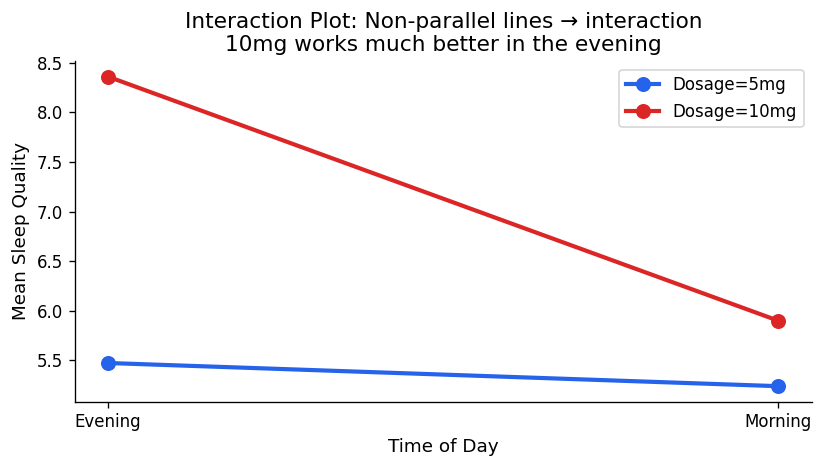

Saved.


In [11]:
n_cell = 50
rng2 = np.random.default_rng(99)
records = []
for dose, time in product([5,10],['Morning','Evening']):
    interaction = 2.0 if (dose==10 and time=='Evening') else 0.0
    y = 5 + (1.0 if dose==10 else 0) + (0.5 if time=='Evening' else 0) + interaction + rng2.normal(0,1,n_cell)
    for yi in y: records.append({'Dosage':f'{dose}mg','Time':time,'Sleep':yi})

df_fact = pd.DataFrame(records)
cell_means = df_fact.groupby(['Dosage','Time'])['Sleep'].mean().unstack()
print('Cell means:'); print(cell_means.round(2))

fig, ax = plt.subplots(figsize=(7,4))
for dose, col in [('5mg',BLUE),('10mg',RED)]:
    m = cell_means.loc[dose]
    ax.plot(m.index, m.values, marker='o', lw=2.5, ms=8, color=col, label=f'Dosage={dose}')
ax.set_xlabel('Time of Day'); ax.set_ylabel('Mean Sleep Quality')
ax.set_title('Interaction Plot: Non-parallel lines → interaction\n10mg works much better in the evening')
ax.legend(); plt.tight_layout()
plt.savefig('figures/04_factorial_design.png',bbox_inches='tight')
plt.show(); print('Saved.')

<a id='6'></a>
## 6. Internal vs. External Validity

**Internal validity** — did the experiment correctly identify a causal relationship?  
**External validity** — does that relationship generalize beyond the study?

Highly controlled lab settings increase internal validity but often narrow the population, reducing external validity.

In [12]:
true_effect_fn = lambda age: 3 + 0.1*(age - 40)   # effect grows with age

def run_study(n, age_range, seed=0):
    rng = np.random.default_rng(seed)
    age = rng.uniform(*age_range, n)
    T   = rng.integers(0,2,n)
    Y   = true_effect_fn(age)*T + 0.05*age + rng.normal(0,2,n)
    ate_est  = Y[T==1].mean() - Y[T==0].mean()
    true_ate = true_effect_fn(np.linspace(*age_range,1000)).mean()
    return ate_est, true_ate

lab_est,   lab_true   = run_study(200, (35,45))
field_est, field_true = run_study(200, (20,80))

print(f'Lab study (ages 35-45)  : estimated ATE={lab_est:.2f}, true ATE={lab_true:.2f}')
print(f'Field study (ages 20-80): estimated ATE={field_est:.2f}, true ATE={field_true:.2f}')
print(f'Lab result applied broadly → generalization error: {abs(lab_est-field_true):.2f}')

Lab study (ages 35-45)  : estimated ATE=2.46, true ATE=3.00
Field study (ages 20-80): estimated ATE=4.05, true ATE=4.00
Lab result applied broadly → generalization error: 1.54


<a id='7'></a>
## 7. Meta-Analysis — Pooling Evidence

Meta-analysis combines estimates from multiple independent studies, weighting each by the inverse of its variance. More precise studies contribute more to the pooled estimate.

True ATE: 2.5
Meta ATE: 2.611 ± 0.129  (95% CI [2.357, 2.864])


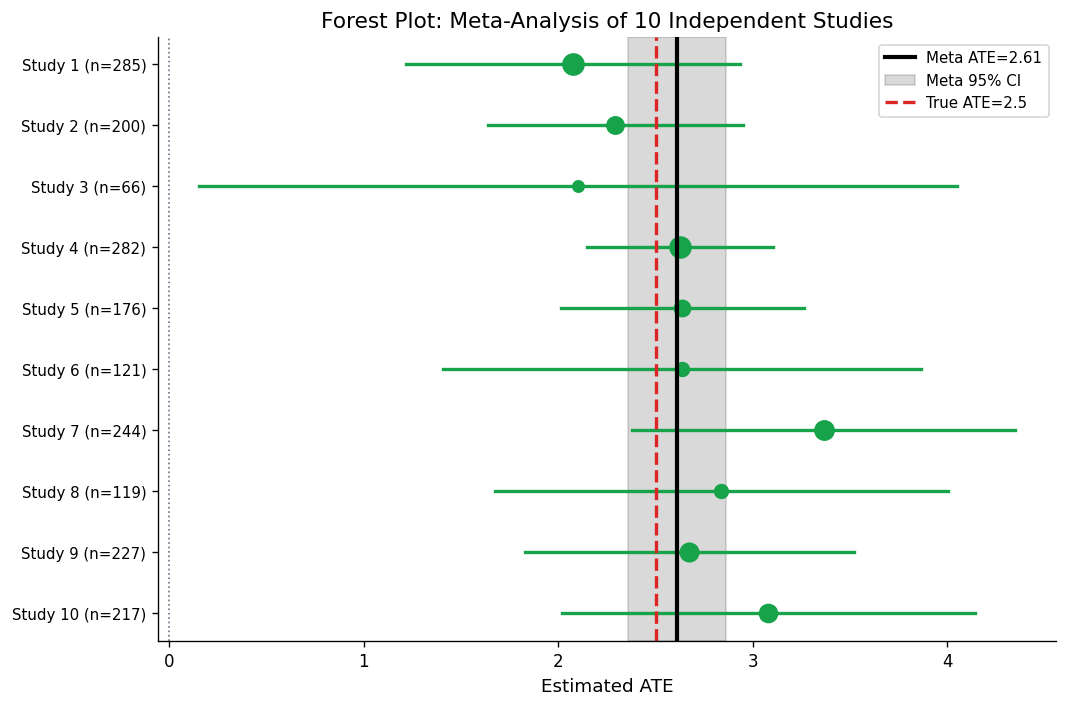

Saved.


In [13]:
true_ate_meta = 2.5
rng3 = np.random.default_rng(7)
studies = []
for i in range(10):
    n_i = rng3.integers(30,300); sigma = rng3.uniform(1,4)
    T = rng3.integers(0,2,n_i)
    Y = true_ate_meta*T + rng3.normal(0,sigma,n_i)
    est = Y[T==1].mean()-Y[T==0].mean()
    se  = sigma*np.sqrt(1/T.sum()+1/max((~T.astype(bool)).sum(),1))
    studies.append({'Study':f'Study {i+1}','n':n_i,'ATE':est,'SE':se,
                    'CI_lo':est-1.96*se,'CI_hi':est+1.96*se})
df_meta = pd.DataFrame(studies)

weights  = 1/df_meta.SE**2
meta_est = (weights*df_meta.ATE).sum()/weights.sum()
meta_se  = np.sqrt(1/weights.sum())
print(f'True ATE: {true_ate_meta}')
print(f'Meta ATE: {meta_est:.3f} ± {meta_se:.3f}  (95% CI [{meta_est-1.96*meta_se:.3f}, {meta_est+1.96*meta_se:.3f}])')

fig, ax = plt.subplots(figsize=(9,6))
y_pos = np.arange(len(df_meta),0,-1)
for i, (_, row) in enumerate(df_meta.iterrows()):
    col = GREEN if row.CI_lo>0 else (RED if row.CI_hi<0 else GRAY)
    ax.plot([row.CI_lo,row.CI_hi],[y_pos[i],y_pos[i]],color=col,lw=2)
    ax.plot(row.ATE, y_pos[i], 'o', color=col, ms=5+8*(row.n/300))
ax.axvline(meta_est,color='black',lw=2.5,label=f'Meta ATE={meta_est:.2f}')
ax.axvspan(meta_est-1.96*meta_se,meta_est+1.96*meta_se,alpha=0.15,color='black',label='Meta 95% CI')
ax.axvline(true_ate_meta,color=RED,lw=2,ls='--',label=f'True ATE={true_ate_meta}')
ax.axvline(0,color=GRAY,lw=1,ls=':')
ax.set_yticks(y_pos); ax.set_yticklabels([f"{r.Study} (n={r.n})" for _,r in df_meta.iterrows()],fontsize=9)
ax.set_xlabel('Estimated ATE')
ax.set_title('Forest Plot: Meta-Analysis of 10 Independent Studies')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('figures/05_meta_analysis.png',bbox_inches='tight')
plt.show(); print('Saved.')

---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Confounding** | Hidden variable correlated with both X and Y → spurious causation |
| **Randomization** | Balances all covariates — measured and unmeasured |
| **Blocking (RBD)** | Remove known variance sources before randomizing → more power |
| **Factorial design** | Only way to detect interactions between factors |
| **Double-blind** | Eliminates both participant and researcher expectation bias |
| **Internal validity** | Did we measure a true causal effect? |
| **External validity** | Does it generalize beyond the study? |
| **Meta-analysis** | Pooled estimate weighted by precision → smaller SE than any single study |

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*